In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

# Configuración visual
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)


In [4]:
df = pd.read_csv('../dataset/bitext_dataset.csv')
print(f"Dimensiones del dataset: {df.shape}")
print(f"Columnas: {df.columns.tolist()}")
df.head()

Dimensiones del dataset: (26872, 2)
Columnas: ['instruction', 'category']


,instruction,category
0,question about cancelling order {{Order Number}},ORDER
1,i have a question about cancelling oorder {{Or...,ORDER
2,i need help cancelling puchase {{Order Number}},ORDER
3,I need to cancel purchase {{Order Number}},ORDER
4,"I cannot afford this order, cancel purchase {{...",ORDER


In [5]:
conteo = df['category'].value_counts()
print(f"Categorías y cantidad de ejemplos:")
print(conteo)
print(f"\nTotal de categorías: {len(conteo)}")

Categorías y cantidad de ejemplos:
category
ACCOUNT         5986
ORDER           3988
REFUND          2992
INVOICE         1999
CONTACT         1999
PAYMENT         1998
FEEDBACK        1997
DELIVERY        1994
SHIPPING        1970
SUBSCRIPTION     999
CANCEL           950
Name: count, dtype: int64

Total de categorías: 11


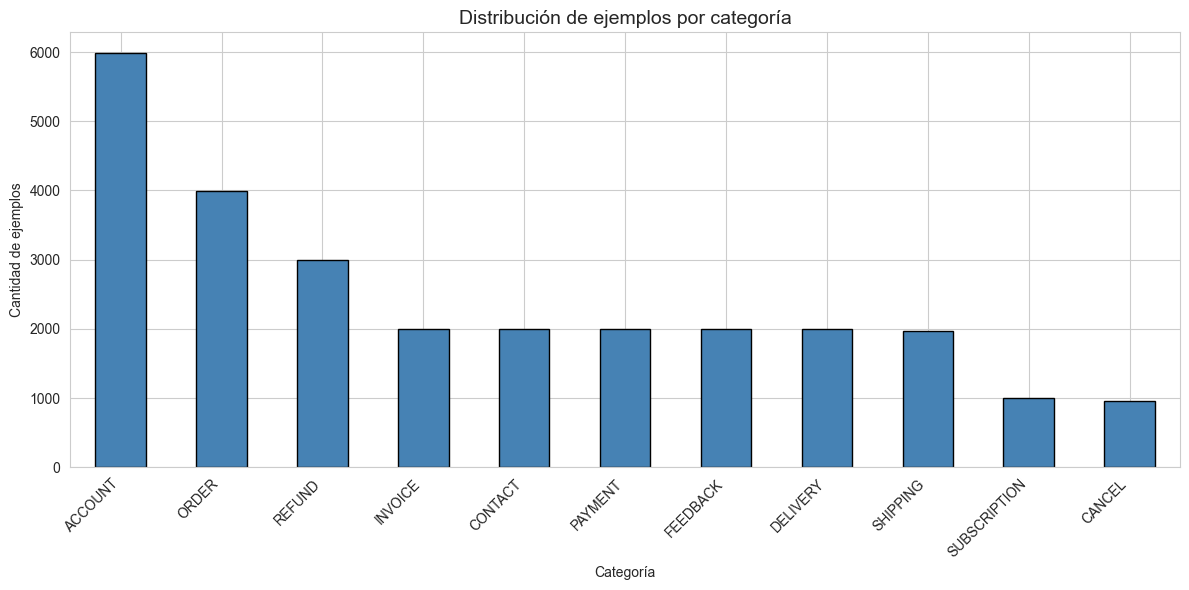

In [9]:
plt.figure(figsize=(12,6))
conteo.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Distribución de ejemplos por categoría', fontsize=14)
plt.xlabel('Categoría')
plt.ylabel('Cantidad de ejemplos')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


In [11]:
for categoria in df['category'].unique():
    ejemplo = df[df['category'] == categoria]['instruction'].iloc[0]
    print(f" [{categoria}]")
    print(f"   {ejemplo}")
    print()

 [ORDER]
   question about cancelling order {{Order Number}}

 [SHIPPING]
   give me information about a delivery address modification

 [CANCEL]
   I can't ifnd the bloody termination charge, I need help

 [INVOICE]
   show me invoice{{Invoice Number}}

 [PAYMENT]
   I try to list your available payment methoids

 [REFUND]
   i do not know hoow i could check ur reimbursement policy

 [FEEDBACK]
   help me to file a claim

 [CONTACT]
   I want help to speak to customer support

 [ACCOUNT]
   new {{Account Type}} acount for wife

 [DELIVERY]
   could you help me check what delivery methods you offer?

 [SUBSCRIPTION]
   i try to unsubscribe to ur companu newsletter



In [12]:
# Buscar todos los placeholders del tipo {{algo}}
placeholders_encontrados = set()
for texto in df['instruction']:
    matches = re.findall(r'\{\{[^}]+\}\}', str(texto))
    placeholders_encontrados.update(matches)

print(f"Placeholders únicos encontrados: {len(placeholders_encontrados)}")
for p in sorted(placeholders_encontrados):
    print(f"  - {p}")

Placeholders únicos encontrados: 9
  - {{Account Category}}
  - {{Account Type}}
  - {{Currency Symbol}}
  - {{Delivery City}}
  - {{Delivery Country}}
  - {{Invoice Number}}
  - {{Order Number}}
  - {{Person Name}}
  - {{Refund Amount}}


In [13]:
df['longitud'] = df['instruction'].str.len()
df['num_palabras'] = df['instruction'].str.split().str.len()

print("Estadísticas de longitud (caracteres):")
print(df['longitud'].describe())
print("\nEstadísticas de cantidad de palabras:")
print(df['num_palabras'].describe())

Estadísticas de longitud (caracteres):
count    26872.000000
mean        46.889513
std         10.897578
min          6.000000
25%         40.000000
50%         48.000000
75%         55.000000
max         92.000000
Name: longitud, dtype: float64

Estadísticas de cantidad de palabras:
count    26872.000000
mean         8.690979
std          2.605004
min          1.000000
25%          7.000000
50%          9.000000
75%         11.000000
max         16.000000
Name: num_palabras, dtype: float64


In [14]:
print(f"Filas duplicadas: {df.duplicated().sum()}")
print(f"Valores nulos por columna:")
print(df.isnull().sum())

Filas duplicadas: 2237
Valores nulos por columna:
instruction     0
category        0
longitud        0
num_palabras    0
dtype: int64
